# Eredivisie Team Ratings
**Attacking & Defensive ratings using PI, ELO, and Glicko-2**

- **PI (Performance Index)**: goal-difference weighted rating, normalised per match
- **ELO**: classic chess-style rating updated after every result
- **Glicko-2**: ELO extension with rating-deviation (confidence) and volatility

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ── paths ──────────────────────────────────────────────────────────────────
MATCHES_CSV = '/Users/marclamberts/Event data/Eredivisie Matches.csv'

In [2]:
# ── load & clean ───────────────────────────────────────────────────────────
raw = pd.read_csv(MATCHES_CSV)

cols = {
    'matchInfo/date':                          'date',
    'matchInfo/week':                          'week',
    'matchInfo/contestant/0/name':             'home',
    'matchInfo/contestant/1/name':             'away',
    'liveData/matchDetails/scores/ft/home':    'home_goals',
    'liveData/matchDetails/scores/ft/away':    'away_goals',
    'liveData/matchDetails/winner':            'winner',
    'liveData/matchDetails/matchStatus':       'status',
}
df = raw[list(cols)].rename(columns=cols).copy()
df = df[df['status'] == 'Played'].copy()
df['date'] = pd.to_datetime(df['date'].str.replace('Z',''), utc=False)
df = df.sort_values('date').reset_index(drop=True)
df['home_goals'] = df['home_goals'].astype(float)
df['away_goals'] = df['away_goals'].astype(float)
df['goal_diff'] = df['home_goals'] - df['away_goals']  # from home perspective

teams = sorted(set(df['home'].unique()) | set(df['away'].unique()))
print(f"Matches: {len(df)}  |  Teams: {len(teams)}")
df.head(3)

Matches: 309  |  Teams: 18


,date,week,home,away,home_goals,away_goals,winner,status,goal_diff
0,2025-08-08,1.0,Fortuna Sittard,Go Ahead Eagles,2.0,2.0,draw,Played,0.0
1,2025-08-09,1.0,PSV,Sparta Rotterdam,6.0,1.0,home,Played,5.0
2,2025-08-09,1.0,NEC,Excelsior,5.0,0.0,home,Played,5.0


## 1 · PI (Performance Index)
Simple cumulative goal-difference based rating, scaled per match played.

- **Attacking PI** = total goals scored per match played  
- **Defensive PI** = total goals conceded per match played (lower = better)  
- **Overall PI** = (Attacking PI − Defensive PI)

In [3]:
def compute_pi(df, teams):
    records = []
    for t in teams:
        home = df[df['home'] == t]
        away = df[df['away'] == t]
        gf = home['home_goals'].sum() + away['away_goals'].sum()
        ga = home['away_goals'].sum() + away['home_goals'].sum()
        mp = len(home) + len(away)
        w  = (home['winner'] == 'home').sum() + (away['winner'] == 'away').sum()
        d  = ((home['winner'] == 'draw').sum() + (away['winner'] == 'draw').sum())
        l  = mp - w - d
        records.append({
            'team': t, 'MP': mp, 'W': w, 'D': d, 'L': l,
            'GF': gf, 'GA': ga, 'GD': gf - ga,
            'Att_PI': round(gf / mp, 3) if mp else 0,
            'Def_PI': round(ga / mp, 3) if mp else 0,
            'PI':     round((gf - ga) / mp, 3) if mp else 0,
        })
    return pd.DataFrame(records).sort_values('PI', ascending=False).reset_index(drop=True)

pi = compute_pi(df, teams)
pi.index += 1
pi

,team,MP,W,D,L,GF,GA,GD,Att_PI,Def_PI,PI
1,PSV,34,27,3,4,101.0,45.0,56.0,2.971,1.324,1.647
2,Feyenoord,34,19,8,7,70.0,44.0,26.0,2.059,1.294,0.765
3,NEC,34,16,11,7,77.0,53.0,24.0,2.265,1.559,0.706
4,Ajax,36,16,14,6,64.0,41.0,23.0,1.778,1.139,0.639
5,Twente,34,15,13,6,59.0,40.0,19.0,1.735,1.176,0.559
6,Utrecht,36,16,8,12,58.0,44.0,14.0,1.611,1.222,0.389
7,AZ,34,14,10,10,58.0,51.0,7.0,1.706,1.500,0.206
8,Heerenveen,35,14,9,12,59.0,56.0,3.0,1.686,1.600,0.086
9,Groningen,35,14,6,15,49.0,47.0,2.0,1.400,1.343,0.057
10,Go Ahead Eagles,34,8,14,12,54.0,53.0,1.0,1.588,1.559,0.029


## 2 · ELO Rating
Classic ELO with goal-difference multiplier.

- Start rating: **1500** for all teams  
- K-factor: **40**  
- Goal-difference multiplier: `log(|GD|+1) + 1` (dampened)

In [4]:
def elo_expected(r_a, r_b):
    return 1 / (1 + 10 ** ((r_b - r_a) / 400))

def gd_multiplier(gd):
    return math.log(abs(gd) + 1, math.e) + 1

def compute_elo(df, teams, K=40, start=1500, home_adv=50):
    ratings = {t: start for t in teams}
    # track attacking / defensive contributions separately
    att = {t: [] for t in teams}   # goals scored per match (weighted by opponent)
    def_ = {t: [] for t in teams}  # goals conceded per match
    history = {t: [] for t in teams}

    for _, row in df.iterrows():
        h, a = row['home'], row['away']
        hg, ag = row['home_goals'], row['away_goals']
        gd = hg - ag

        r_h = ratings[h] + home_adv
        r_a = ratings[a]
        E_h = elo_expected(r_h, r_a)
        E_a = 1 - E_h

        S_h = 1 if gd > 0 else (0.5 if gd == 0 else 0)
        S_a = 1 - S_h

        mult = gd_multiplier(gd)
        delta_h = K * mult * (S_h - E_h)
        delta_a = K * mult * (S_a - E_a)

        ratings[h] += delta_h
        ratings[a] += delta_a

        att[h].append(hg); att[a].append(ag)
        def_[h].append(ag); def_[a].append(hg)
        history[h].append(ratings[h]); history[a].append(ratings[a])

    records = []
    for t in teams:
        n = len(att[t])
        records.append({
            'team': t,
            'ELO': round(ratings[t], 1),
            'ELO_Att': round(np.mean(att[t]) * 100, 1) if n else 0,   # goals scored per match × 100
            'ELO_Def': round(np.mean(def_[t]) * 100, 1) if n else 0,  # goals conceded per match × 100
            'history': history[t],
        })
    return pd.DataFrame(records).sort_values('ELO', ascending=False).reset_index(drop=True), ratings

elo_df, elo_final = compute_elo(df, teams)
elo_df.index += 1
elo_df.drop(columns='history')

,team,ELO,ELO_Att,ELO_Def
1,PSV,1799.0,297.1,132.4
2,Twente,1656.9,173.5,117.6
3,Utrecht,1636.5,161.1,122.2
4,Feyenoord,1634.4,205.9,129.4
5,NEC,1618.7,226.5,155.9
6,Ajax,1597.8,177.8,113.9
7,AZ,1557.9,170.6,150.0
8,Telstar,1532.9,144.1,161.8
9,Heerenveen,1513.5,168.6,160.0
10,Groningen,1494.9,140.0,134.3


## 3 · Glicko-2 Rating
Extends ELO with **Rating Deviation (RD)** (uncertainty) and **Volatility** (consistency).

Parameters (defaults from Glicko-2 paper):
- Initial rating: **1500**, RD: **350**, Volatility: **0.06**
- τ (system constant): **0.5**

Each **matchday** is treated as one rating period.

In [5]:
# ── Glicko-2 implementation ────────────────────────────────────────────────
MU0, PHI0, SIGMA0, TAU = 1500, 350, 0.06, 0.5
GLICKO_SCALE = 173.7178  # converts to internal μ scale

def g(phi): return 1 / math.sqrt(1 + 3 * phi**2 / math.pi**2)
def E(mu, mu_j, phi_j): return 1 / (1 + math.exp(-g(phi_j) * (mu - mu_j)))

def new_sigma(sigma, delta, phi, v, tau=TAU):
    a = math.log(sigma**2)
    eps = 1e-6
    def f(x):
        ex = math.exp(x)
        return (ex * (delta**2 - phi**2 - v - ex)) / (2 * (phi**2 + v + ex)**2) - (x - a) / tau**2
    A = a
    if delta**2 > phi**2 + v:
        B = math.log(delta**2 - phi**2 - v)
    else:
        k = 1
        while f(a - k * tau) < 0:
            k += 1
        B = a - k * tau
    fA, fB = f(A), f(B)
    for _ in range(100):
        C = A + (A - B) * fA / (fB - fA)
        fC = f(C)
        if fC * fB < 0: A, fA = B, fB
        else: fA = fA / 2
        B, fB = C, fC
        if abs(B - A) < eps: break
    return math.exp(A / 2)

def update_glicko2(mu, phi, sigma, opponents, scores):
    """opponents: list of (mu_j, phi_j); scores: list of s in {0,0.5,1}"""
    if not opponents:
        phi_star = math.sqrt(phi**2 + sigma**2)
        return mu, min(phi_star, PHI0 / GLICKO_SCALE), sigma

    v = sum(g(phi_j)**2 * E(mu, mu_j, phi_j) * (1 - E(mu, mu_j, phi_j))
            for mu_j, phi_j in opponents)**-1
    delta = v * sum(g(phi_j) * (s - E(mu, mu_j, phi_j))
                    for (mu_j, phi_j), s in zip(opponents, scores))

    sigma_new = new_sigma(sigma, delta, phi, v)
    phi_star  = math.sqrt(phi**2 + sigma_new**2)
    phi_new   = 1 / math.sqrt(1/phi_star**2 + 1/v)
    mu_new    = mu + phi_new**2 * sum(g(phi_j) * (s - E(mu, mu_j, phi_j))
                                       for (mu_j, phi_j), s in zip(opponents, scores))
    return mu_new, phi_new, sigma_new

def compute_glicko2(df, teams):
    # internal scale
    mu    = {t: (MU0 - 1500) / GLICKO_SCALE for t in teams}
    phi   = {t: PHI0 / GLICKO_SCALE          for t in teams}
    sigma = {t: SIGMA0                        for t in teams}

    att_goals = {t: [] for t in teams}
    def_goals = {t: [] for t in teams}

    # group by matchday (use date as period)
    for date, period_df in df.groupby('date'):
        # collect opponents for this period per team
        period_opps  = {t: [] for t in teams}
        period_scores= {t: [] for t in teams}

        for _, row in period_df.iterrows():
            h, a = row['home'], row['away']
            hg, ag = row['home_goals'], row['away_goals']
            gd = hg - ag

            # score in {0, 0.5, 1}
            s_h = 1.0 if gd > 0 else (0.5 if gd == 0 else 0.0)
            s_a = 1.0 - s_h

            # GD-adjusted score (cap at 0/1)
            margin = min(abs(gd) * 0.1, 0.4)
            s_h = min(1.0, s_h + (margin if gd > 0 else (-margin if gd < 0 else 0)))
            s_a = 1.0 - s_h

            period_opps[h].append((mu[a], phi[a]))
            period_scores[h].append(s_h)
            period_opps[a].append((mu[h], phi[h]))
            period_scores[a].append(s_a)

            att_goals[h].append(hg); att_goals[a].append(ag)
            def_goals[h].append(ag); def_goals[a].append(hg)

        # update all teams
        new_mu, new_phi, new_sigma = {}, {}, {}
        for t in teams:
            new_mu[t], new_phi[t], new_sigma[t] = update_glicko2(
                mu[t], phi[t], sigma[t], period_opps[t], period_scores[t])
        mu, phi, sigma = new_mu, new_phi, new_sigma

    records = []
    for t in teams:
        r   = round(mu[t] * GLICKO_SCALE + 1500, 1)
        rd  = round(phi[t] * GLICKO_SCALE, 1)
        vol = round(sigma[t], 5)
        n   = len(att_goals[t])
        records.append({
            'team':      t,
            'G2_Rating': r,
            'G2_RD':     rd,
            'G2_Vol':    vol,
            'G2_Low':    round(r - 2*rd, 1),
            'G2_High':   round(r + 2*rd, 1),
            'G2_Att':    round(np.mean(att_goals[t]) * 100, 1) if n else 0,
            'G2_Def':    round(np.mean(def_goals[t]) * 100, 1) if n else 0,
        })
    return pd.DataFrame(records).sort_values('G2_Rating', ascending=False).reset_index(drop=True)

g2_df = compute_glicko2(df, teams)
g2_df.index += 1
g2_df

,team,G2_Rating,G2_RD,G2_Vol,G2_Low,G2_High,G2_Att,G2_Def
1,PSV,1894.2,118.5,0.06004,1657.2,2131.2,297.1,132.4
2,Twente,1648.4,88.7,0.06000,1471.0,1825.8,173.5,117.6
3,Feyenoord,1641.7,93.3,0.06001,1455.1,1828.3,205.9,129.4
4,NEC,1617.6,90.6,0.06002,1436.4,1798.8,226.5,155.9
5,Utrecht,1607.1,84.5,0.06001,1438.1,1776.1,161.1,122.2
6,Ajax,1603.1,84.5,0.05999,1434.1,1772.1,177.8,113.9
7,Heerenveen,1545.5,86.5,0.06001,1372.5,1718.5,168.6,160.0
8,AZ,1540.4,88.3,0.06000,1363.8,1717.0,170.6,150.0
9,Telstar,1476.6,89.4,0.06000,1297.8,1655.4,144.1,161.8
10,Groningen,1472.1,86.1,0.06002,1299.9,1644.3,140.0,134.3


## 4 · Combined Ratings Table

In [6]:
combined = pi[['team','MP','W','D','L','GF','GA','GD','Att_PI','Def_PI','PI']].merge(
    elo_df[['team','ELO','ELO_Att','ELO_Def']], on='team'
).merge(
    g2_df[['team','G2_Rating','G2_RD','G2_Vol','G2_Low','G2_High','G2_Att','G2_Def']], on='team'
).sort_values('G2_Rating', ascending=False).reset_index(drop=True)

combined.index += 1
combined

,team,MP,W,D,L,GF,GA,GD,Att_PI,Def_PI,...,ELO,ELO_Att,ELO_Def,G2_Rating,G2_RD,G2_Vol,G2_Low,G2_High,G2_Att,G2_Def
1,PSV,34,27,3,4,101.0,45.0,56.0,2.971,1.324,...,1799.0,297.1,132.4,1894.2,118.5,0.06004,1657.2,2131.2,297.1,132.4
2,Twente,34,15,13,6,59.0,40.0,19.0,1.735,1.176,...,1656.9,173.5,117.6,1648.4,88.7,0.06000,1471.0,1825.8,173.5,117.6
3,Feyenoord,34,19,8,7,70.0,44.0,26.0,2.059,1.294,...,1634.4,205.9,129.4,1641.7,93.3,0.06001,1455.1,1828.3,205.9,129.4
4,NEC,34,16,11,7,77.0,53.0,24.0,2.265,1.559,...,1618.7,226.5,155.9,1617.6,90.6,0.06002,1436.4,1798.8,226.5,155.9
5,Utrecht,36,16,8,12,58.0,44.0,14.0,1.611,1.222,...,1636.5,161.1,122.2,1607.1,84.5,0.06001,1438.1,1776.1,161.1,122.2
6,Ajax,36,16,14,6,64.0,41.0,23.0,1.778,1.139,...,1597.8,177.8,113.9,1603.1,84.5,0.05999,1434.1,1772.1,177.8,113.9
7,Heerenveen,35,14,9,12,59.0,56.0,3.0,1.686,1.600,...,1513.5,168.6,160.0,1545.5,86.5,0.06001,1372.5,1718.5,168.6,160.0
8,AZ,34,14,10,10,58.0,51.0,7.0,1.706,1.500,...,1557.9,170.6,150.0,1540.4,88.3,0.06000,1363.8,1717.0,170.6,150.0
9,Telstar,34,9,10,15,49.0,55.0,-6.0,1.441,1.618,...,1532.9,144.1,161.8,1476.6,89.4,0.06000,1297.8,1655.4,144.1,161.8
10,Groningen,35,14,6,15,49.0,47.0,2.0,1.400,1.343,...,1494.9,140.0,134.3,1472.1,86.1,0.06002,1299.9,1644.3,140.0,134.3


In [7]:
# export to Excel
out_path = '/Users/marclamberts/Event data/Eredivisie/Ratings/eredivisie_ratings.xlsx'
with pd.ExcelWriter(out_path, engine='openpyxl') as writer:
    combined.to_excel(writer, sheet_name='Combined')
    pi.to_excel(writer, sheet_name='PI')
    elo_df.drop(columns='history').to_excel(writer, sheet_name='ELO')
    g2_df.to_excel(writer, sheet_name='Glicko2')
print('Saved:', out_path)

Saved: /Users/marclamberts/Event data/Eredivisie/Ratings/eredivisie_ratings.xlsx


## 5 · Attacking vs Defensive Rating Chart

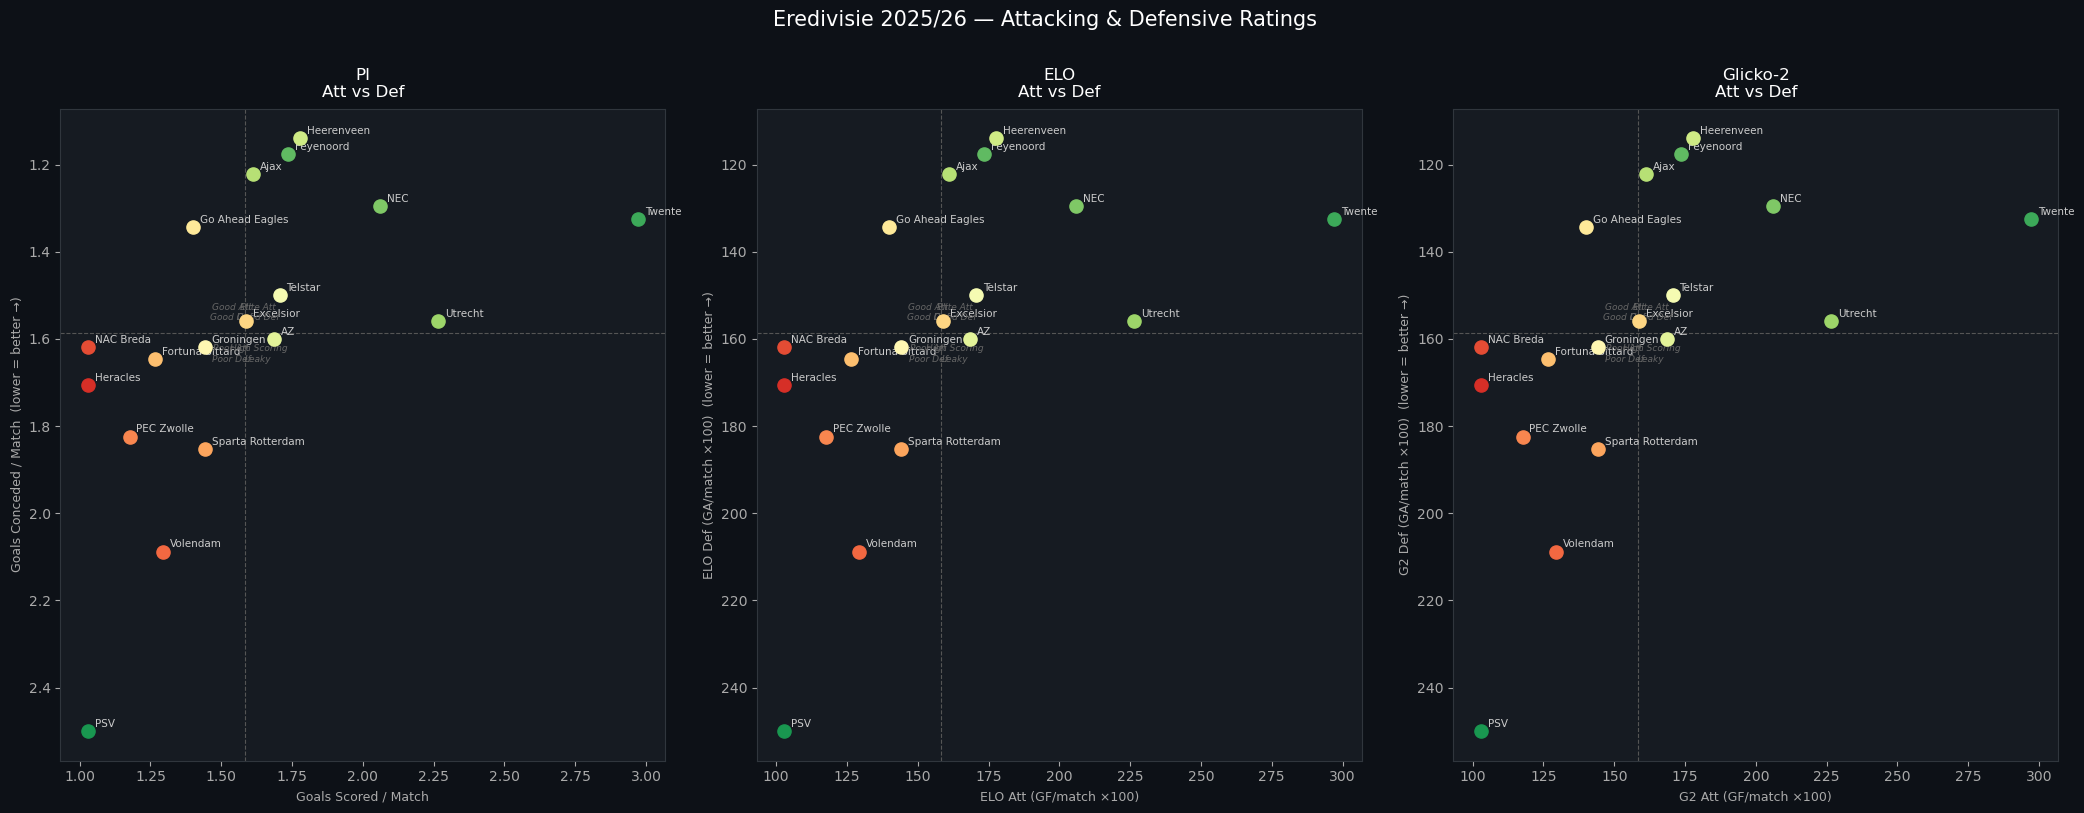

Saved: /Users/marclamberts/Event data/Eredivisie/Ratings/att_def_ratings.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(21, 8))
fig.patch.set_facecolor('#0d1117')

plot_data = [
    (combined['Att_PI'], combined['Def_PI'], 'PI', 'Goals Scored / Match', 'Goals Conceded / Match'),
    (combined['ELO_Att'], combined['ELO_Def'], 'ELO', 'ELO Att (GF/match ×100)', 'ELO Def (GA/match ×100)'),
    (combined['G2_Att'], combined['G2_Def'], 'Glicko-2', 'G2 Att (GF/match ×100)', 'G2 Def (GA/match ×100)'),
]

colors = plt.cm.RdYlGn(np.linspace(0.9, 0.1, len(combined)))

for ax, (att, def_, title, xlabel, ylabel) in zip(axes, plot_data):
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#aaaaaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

    ax.axvline(att.mean(), color='#555', lw=0.8, ls='--')
    ax.axhline(def_.mean(), color='#555', lw=0.8, ls='--')

    for i, (_, row) in enumerate(combined.iterrows()):
        x = att.iloc[i-1] if isinstance(att, pd.Series) else att[i]
        y = def_.iloc[i-1] if isinstance(def_, pd.Series) else def_[i]
        ax.scatter(x, y, color=colors[i], s=90, zorder=5)
        ax.annotate(row['team'], (x, y), textcoords='offset points',
                    xytext=(5, 3), fontsize=7.5, color='#cccccc')

    ax.invert_yaxis()  # lower GA = better = top of chart
    ax.set_xlabel(xlabel, color='#aaaaaa', fontsize=9)
    ax.set_ylabel(ylabel + '  (lower = better →)', color='#aaaaaa', fontsize=9)
    ax.set_title(f'{title}\nAtt vs Def', color='white', fontsize=12, pad=8)

    # quadrant labels
    xm, ym = att.mean(), def_.mean()
    for (tx, ty, lbl) in [(xm*0.97, ym*0.97, 'Good Att\nGood Def'),
                           (xm*1.03, ym*0.97, 'Elite Att\nGood Def'),
                           (xm*0.97, ym*1.03, 'Poor Att\nPoor Def'),
                           (xm*1.03, ym*1.03, 'High Scoring\nLeaky')]:
        ax.text(tx, ty, lbl, fontsize=6.5, color='#666', ha='center', va='center', style='italic')

plt.suptitle('Eredivisie 2025/26 — Attacking & Defensive Ratings', color='white',
             fontsize=15, y=1.01)
plt.tight_layout()
chart_path = '/Users/marclamberts/Event data/Eredivisie/Ratings/att_def_ratings.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved:', chart_path)

## 6 · ELO Progression Over Time

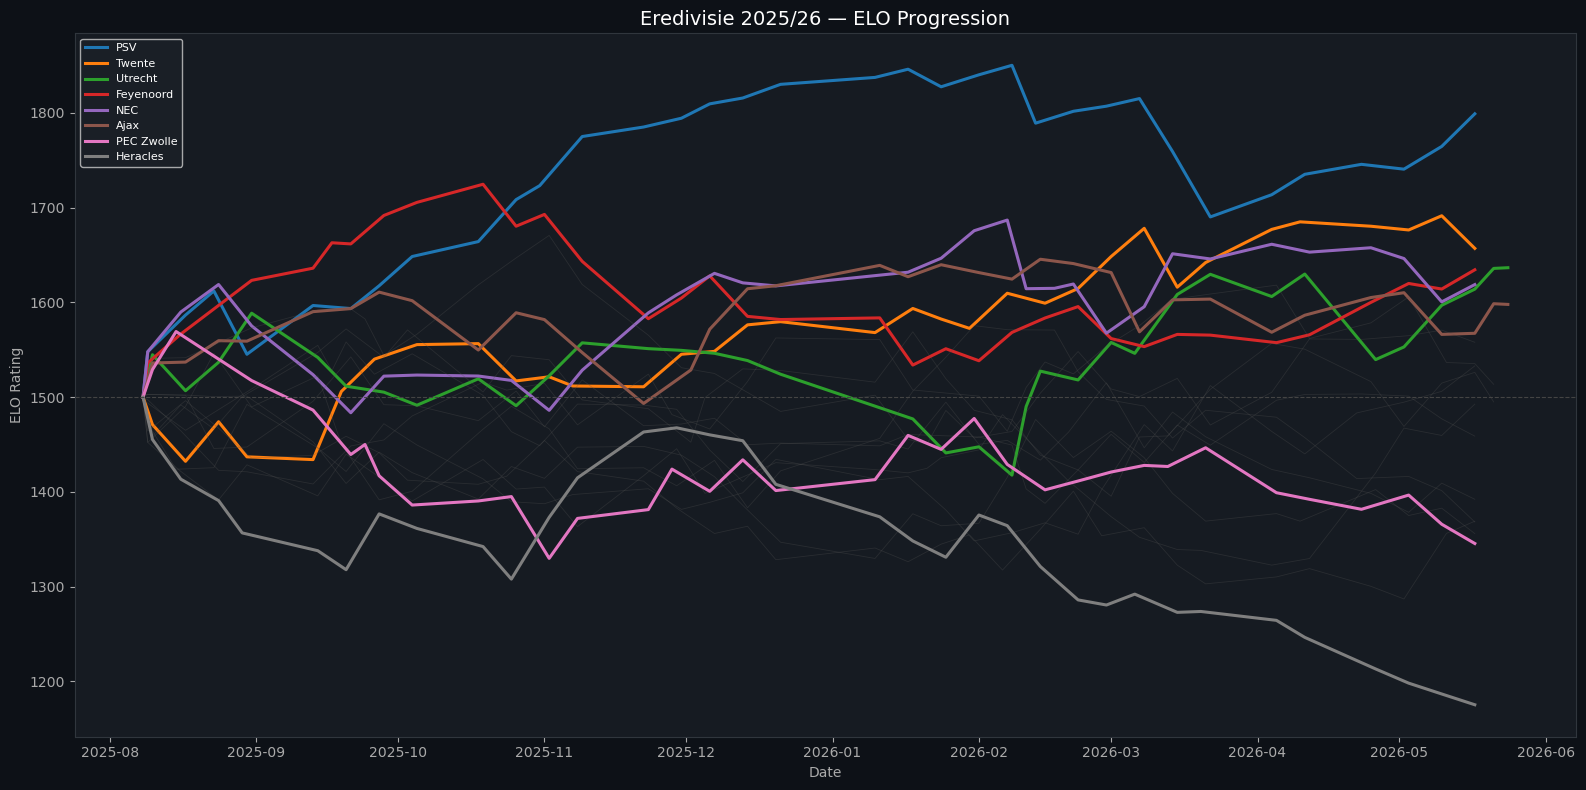

Saved: /Users/marclamberts/Event data/Eredivisie/Ratings/elo_progression.png


In [9]:
# rebuild ELO keeping full history per team
def compute_elo_history(df, teams, K=40, start=1500, home_adv=50):
    ratings = {t: start for t in teams}
    history = {t: [start] for t in teams}
    dates   = {t: [df['date'].min()] for t in teams}

    for _, row in df.iterrows():
        h, a = row['home'], row['away']
        gd = row['home_goals'] - row['away_goals']
        r_h = ratings[h] + home_adv
        r_a = ratings[a]
        E_h = elo_expected(r_h, r_a)
        S_h = 1 if gd > 0 else (0.5 if gd == 0 else 0)
        mult = gd_multiplier(gd)
        ratings[h] += K * mult * (S_h - E_h)
        ratings[a] += K * mult * ((1-S_h) - (1-E_h))
        for t, r in [(h, ratings[h]), (a, ratings[a])]:
            history[t].append(r)
            dates[t].append(row['date'])
    return history, dates

hist, dates_hist = compute_elo_history(df, teams)

# highlight top 6 + bottom 2 by final ELO
final_elo = {t: hist[t][-1] for t in teams}
sorted_teams = sorted(final_elo, key=final_elo.get, reverse=True)
highlight = sorted_teams[:6] + sorted_teams[-2:]

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')

cmap = plt.cm.tab10
for i, t in enumerate(sorted_teams):
    lw = 2.2 if t in highlight else 0.6
    alpha = 1.0 if t in highlight else 0.3
    color = cmap(i % 10) if t in highlight else '#555'
    ax.plot(dates_hist[t], hist[t], lw=lw, alpha=alpha, color=color, label=t if t in highlight else None)

ax.axhline(1500, color='#444', lw=0.8, ls='--')
ax.set_xlabel('Date', color='#aaaaaa')
ax.set_ylabel('ELO Rating', color='#aaaaaa')
ax.set_title('Eredivisie 2025/26 — ELO Progression', color='white', fontsize=14)
ax.legend(facecolor='#1c2128', labelcolor='white', fontsize=8, loc='upper left')
plt.tight_layout()
elo_chart = '/Users/marclamberts/Event data/Eredivisie/Ratings/elo_progression.png'
plt.savefig(elo_chart, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved:', elo_chart)

## 7 · Glicko-2 Rating ± 2 RD (95% interval)

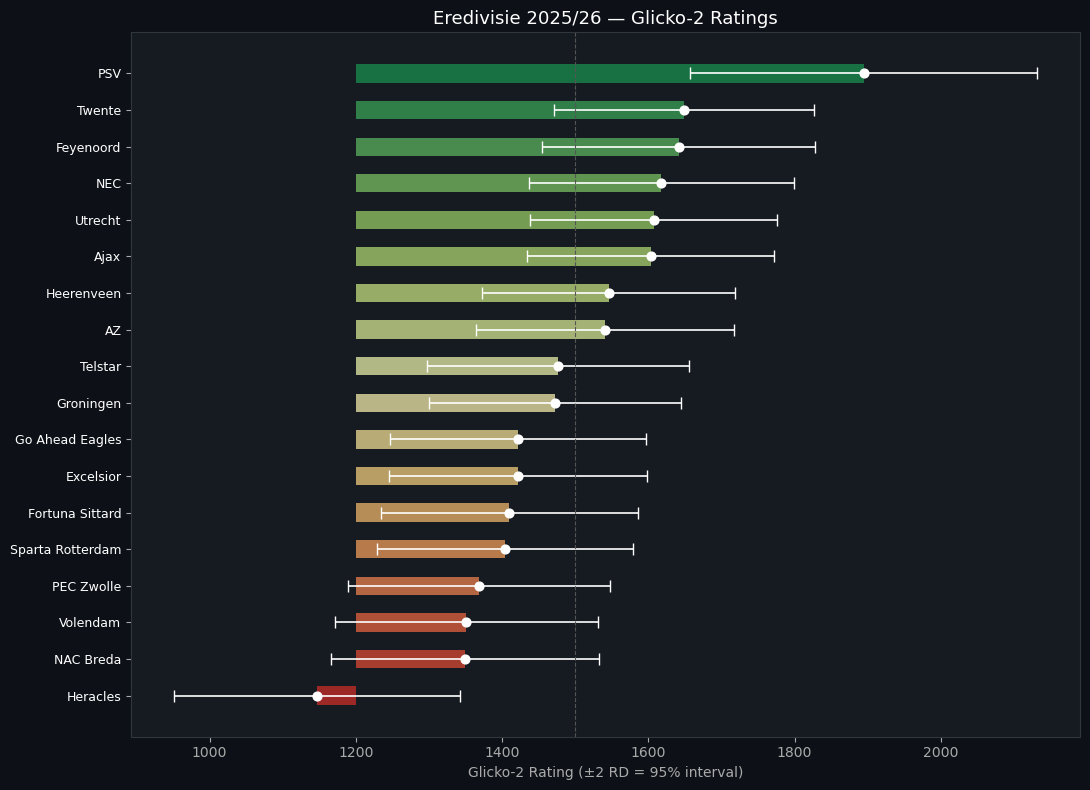

Saved: /Users/marclamberts/Event data/Eredivisie/Ratings/glicko2_ratings.png


In [10]:
plot_g2 = g2_df.sort_values('G2_Rating', ascending=True).copy()

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')

y = np.arange(len(plot_g2))
xerr = np.array([plot_g2['G2_Rating'] - plot_g2['G2_Low'],
                 plot_g2['G2_High'] - plot_g2['G2_Rating']])

colors_g2 = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(plot_g2)))
ax.barh(y, plot_g2['G2_Rating'] - 1200, left=1200, color=colors_g2, alpha=0.7, height=0.5)
ax.errorbar(plot_g2['G2_Rating'], y, xerr=xerr, fmt='none', color='white', capsize=4, lw=1.2)
ax.scatter(plot_g2['G2_Rating'], y, color='white', s=40, zorder=5)

ax.set_yticks(y)
ax.set_yticklabels(plot_g2['team'], color='white', fontsize=9)
ax.set_xlabel('Glicko-2 Rating (±2 RD = 95% interval)', color='#aaaaaa')
ax.set_title('Eredivisie 2025/26 — Glicko-2 Ratings', color='white', fontsize=13)
ax.axvline(1500, color='#555', ls='--', lw=0.8)
plt.tight_layout()
g2_chart = '/Users/marclamberts/Event data/Eredivisie/Ratings/glicko2_ratings.png'
plt.savefig(g2_chart, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved:', g2_chart)

## 8 · Summary: All Three Systems Side by Side

In [11]:
# rank each team in each system
summary = combined[['team','PI','ELO','G2_Rating']].copy()
summary['PI_rank']  = summary['PI'].rank(ascending=False).astype(int)
summary['ELO_rank'] = summary['ELO'].rank(ascending=False).astype(int)
summary['G2_rank']  = summary['G2_Rating'].rank(ascending=False).astype(int)
summary['avg_rank'] = ((summary['PI_rank'] + summary['ELO_rank'] + summary['G2_rank']) / 3).round(1)
summary = summary.sort_values('avg_rank').reset_index(drop=True)
summary.index += 1
summary

,team,PI,ELO,G2_Rating,PI_rank,ELO_rank,G2_rank,avg_rank
1,PSV,1.647,1799.0,1894.2,1,1,1,1.0
2,Twente,0.559,1656.9,1648.4,5,2,2,3.0
3,Feyenoord,0.765,1634.4,1641.7,2,4,3,3.0
4,NEC,0.706,1618.7,1617.6,3,5,4,4.0
5,Utrecht,0.389,1636.5,1607.1,6,3,5,4.7
6,Ajax,0.639,1597.8,1603.1,4,6,6,5.3
7,AZ,0.206,1557.9,1540.4,7,7,8,7.3
8,Heerenveen,0.086,1513.5,1545.5,8,9,7,8.0
9,Telstar,-0.176,1532.9,1476.6,11,8,9,9.3
10,Groningen,0.057,1494.9,1472.1,9,10,10,9.7
